## Ideas / Plan of Action

### Training set optimization

#### Basic approaches

Try:

- CDmean, PEVmean, Random
- GBLUP, NN, GNN

#### More advanced approaches

- Data shapley
- Tracin
- GLISTER
- GRAD-MATCH
---
- CDMean on gblup, --> Test also on nn?
- Pruning with EL2N/Tracin --> Test also on gblup?
- Compare with random
- Analysis of selected sets (which individuals / islands are selected?)

### Tracin

- Removal curves (0, 10, 20 \% etc.)
- Weighted retraining (weighted by the tracin score)
- Iterative pruning (recompute tracin scores after each pruning step)



In [1]:
import pandas as pd

path = "outputs/tracin_multi/combined_removal_curves.csv"
df = pd.read_csv(path)

summary = (
    df.groupby(["method", "removal_fraction"])
      .agg(
          n=("corr_eval", "size"),
          corr_mean=("corr_eval", "mean"),
          corr_median=("corr_eval", "median"),
          corr_std=("corr_eval", "std"),
          mse_mean=("mse_adj", "mean"),
          mse_median=("mse_adj", "median"),
          mse_std=("mse_adj", "std"),
      )
      .reset_index()
      .sort_values(["method", "removal_fraction"])
)

summary.to_csv("outputs/tracin_multi/summary_table.csv", index=False)
print(summary)

    method  removal_fraction   n  corr_mean  corr_median  corr_std  mse_mean  \
0   random               0.0  40   0.161444     0.142198  0.066129  1.286078   
1   random               0.1  40   0.167960     0.154498  0.067755  1.286063   
2   random               0.2  40   0.150089     0.136400  0.080752  1.280944   
3   random               0.3  40   0.144419     0.149434  0.076002  1.286663   
4   random               0.4  40   0.137980     0.121351  0.072446  1.291569   
5   random               0.5  40   0.126176     0.121451  0.084866  1.281408   
6   tracin               0.0  40   0.170688     0.174193  0.080680  1.290432   
7   tracin               0.1  40   0.136569     0.136462  0.068243  1.291338   
8   tracin               0.2  40   0.110926     0.112259  0.065512  1.306638   
9   tracin               0.3  40   0.110767     0.112743  0.056557  1.330655   
10  tracin               0.4  40   0.130519     0.126993  0.056702  1.356600   
11  tracin               0.5  40   0.100

In [2]:
from pathlib import Path
import pandas as pd

scores_dir = Path("outputs/tracin_multi")
score_files = sorted(scores_dir.glob("tracin_scores_island_*_cal_*_seed_*.csv"))

rows = []
for file_path in score_files:
    df_scores = pd.read_csv(file_path)
    island = int(file_path.name.split("_island_")[1].split("_cal_")[0])
    seed = int(file_path.name.split("_seed_")[1].split(".csv")[0])
    pct_negative = (df_scores["score"] < 0).mean() * 100.0
    rows.append({"island": island, "seed": seed, "pct_negative": pct_negative})

neg_df = pd.DataFrame(rows)
neg_summary = (
    neg_df.groupby("island", as_index=False)["pct_negative"]
    .mean()
    .rename(columns={"pct_negative": "pct_negative_mean"})
    .sort_values("island")
)

neg_summary

,island,pct_negative_mean
0,0,44.316959
1,3,38.626204
2,5,35.219745
3,9,36.461761


/tmp/ipykernel_695553/3799617829.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[str(i) for i in islands], showfliers=False)


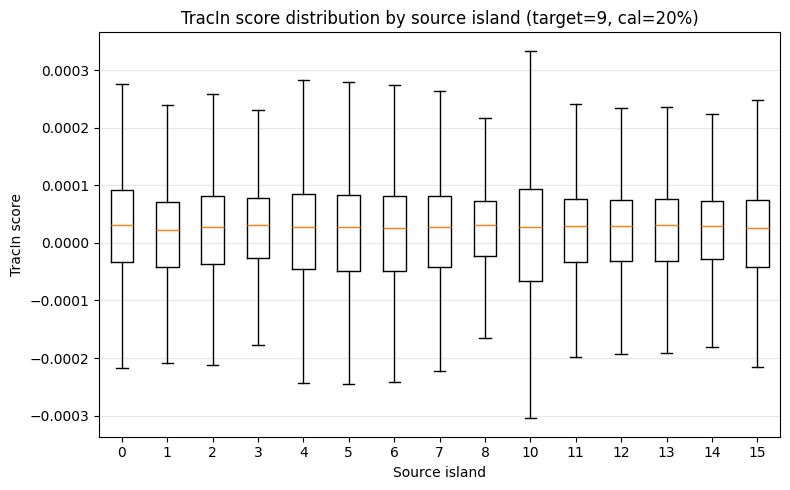

In [6]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

def plot_tracin_scores_by_source_island(target_island, cal_fraction=0.2, exclude_target=True):
    scores_dir = Path("outputs/tracin_multi")
    cal_tag = f"{int(round(cal_fraction * 100)):02d}"
    pattern = f"tracin_scores_island_{target_island}_cal_{cal_tag}_seed_*.csv"
    score_files = sorted(scores_dir.glob(pattern))
    if not score_files:
        raise FileNotFoundError(f"No score files found for target_island={target_island}, cal={cal_tag}")

    rows = []
    for file_path in score_files:
        df_scores = pd.read_csv(file_path)
        df_scores["seed"] = int(file_path.name.split("_seed_")[1].split(".csv")[0])
        rows.append(df_scores)
    scores = pd.concat(rows, ignore_index=True)

    if exclude_target:
        scores = scores[scores["island"] != target_island]

    islands = sorted(scores["island"].unique().tolist())
    data = [scores.loc[scores["island"] == isl, "score"].to_numpy() for isl in islands]

    plt.figure(figsize=(max(8, 0.5 * len(islands)), 5))
    plt.boxplot(data, labels=[str(i) for i in islands], showfliers=False)
    plt.xlabel("Source island")
    plt.ylabel("TracIn score")
    plt.title(f"TracIn score distribution by source island (target={target_island}, cal={cal_tag}%)")
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

# Example:
plot_tracin_scores_by_source_island(target_island=9, cal_fraction=0.2)